# Regularized Regression — Notebook 02 · Lasso and Coordinate Descent

**Regularized Regression — From Likelihood to Lasso**

Covers **Task 3**: soft-thresholding derived and implemented, cyclic coordinate descent, verification against scikit-learn, and the $p \gg n$ new-city selection problem where the decoys bite.

---

### How to run this

Put `uber_surge_mumbai.csv` (and, for notebook 02, `new_city_features.csv` and
`new_city_truth.csv`) in a `data/` folder beside this notebook, or upload them to your
Colab session. If the files are missing, the next cell regenerates them from the same
seed, so nothing here breaks either way.

In [1]:
import os, sys, json, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True, linewidth=110)
pd.set_option('display.width', 120, 'display.max_columns', 30)

# --- a consistent look for every figure in this course -----------------------
plt.rcParams.update({
    'figure.figsize': (9, 4.6), 'figure.dpi': 110,
    'axes.grid': True, 'grid.alpha': .28, 'grid.linewidth': .7,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#c9cbc3', 'axes.labelcolor': '#4c514f',
    'axes.titlesize': 12, 'axes.titleweight': '600', 'axes.labelsize': 10,
    'xtick.color': '#767d7a', 'ytick.color': '#767d7a',
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.frameon': False, 'legend.fontsize': 9,
    'font.size': 10, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
})
C = {'ols': '#767d7a', 'ridge': '#2b5fa8', 'lasso': '#b4700c',
     'enet': '#5b4bb5', 'accent': '#1f6f5c', 'rose': '#b03a52'}

# Look in the usual places: beside the notebook, in ./data, or one level up
# (which is where the repo keeps them if you opened this from notebooks/).
SEARCH = ['data', '.', '../data', '..', '../../data']

def load(name):
    """Load a course CSV, regenerating it from the seed if it cannot be found."""
    for d in SEARCH:
        path = os.path.join(d, name)
        if os.path.exists(path):
            return pd.read_csv(path)
    for cand in ('scripts/make_data.py', 'make_data.py', '../scripts/make_data.py'):
        if os.path.exists(cand):
            subprocess.run([sys.executable, cand], check=True)
            return load(name)
    raise FileNotFoundError(
        f"{name} not found. Download it from the course site's Data page and put it "
        f"in a data/ folder beside this notebook.")

df = load('uber_surge_mumbai.csv')
print(f'{len(df)} trips, {df.shape[1]} columns')
df.head(3)

200 trips, 19 columns


,trip_id,zone,hour,is_peak,is_weekend,is_rain,is_event_nearby,is_airport_pickup,traffic_speed_kmph,drivers_available_500m,open_requests_500m,historical_demand,distance_km,time_min,base_fare_inr,surge_additive_inr,final_fare_inr,demand_supply_ratio,is_bad_weather
0,1,Powai,2,0,1,0,0,0,43.4,31,13,14.0,18.21,33.6,325.7,27.8,353.5,0.419,0
1,2,Lower Parel,18,1,0,1,1,0,22.8,6,46,46.2,15.06,42.7,306.1,150.0,456.1,7.667,1
2,3,Andheri East,15,0,0,0,1,0,47.3,17,25,26.4,3.24,7.8,94.5,65.7,160.2,1.471,0


In [2]:
# ---------------------------------------------------------------------------
# Conventions used throughout this course. Read these once; they save hours.
#
#   Objective (identical to sklearn's ElasticNet, including the 1/2n):
#       (1/2n)||y - Xw||^2  +  alpha*rho*||w||_1  +  (alpha*(1-rho)/2)*||w||^2
#
#   So the Ridge CLOSED FORM needs  n*alpha  where sklearn's Ridge takes alpha:
#       w = (X^T X + n*alpha*I)^-1 X^T y
#
#   Standardize on the TRAINING rows only, then apply that scaler to the test
#   rows. Split by time, never shuffled: trips 1-150 train, 151-200 test.
# ---------------------------------------------------------------------------
BASE8 = ['is_peak', 'is_rain', 'traffic_speed_kmph', 'drivers_available_500m',
         'is_event_nearby', 'is_airport_pickup', 'is_weekend', 'open_requests_500m']
SHORT = {'is_peak': 'is_peak', 'is_rain': 'is_rain',
         'traffic_speed_kmph': 'traffic_speed', 'drivers_available_500m': 'drivers_avail',
         'is_event_nearby': 'is_event', 'is_airport_pickup': 'is_airport',
         'is_weekend': 'is_weekend', 'open_requests_500m': 'open_requests',
         'is_bad_weather': 'is_bad_weather'}
N_TRAIN, SIGMA, TAU = 150, 10.0, 1.0

def split(frame, features):
    X = frame[features].to_numpy(float)
    y = frame['surge_additive_inr'].to_numpy(float)
    return X[:N_TRAIN], X[N_TRAIN:], y[:N_TRAIN], y[N_TRAIN:]

def standardize(Xtr, Xte):
    mu, sd = Xtr.mean(0), Xtr.std(0)
    sd = np.where(sd == 0, 1e-8, sd)
    return (Xtr - mu) / sd, (Xte - mu) / sd, mu, sd

def rmse(y, yhat):
    return float(np.sqrt(np.mean((y - yhat) ** 2)))

def r2(y, yhat):
    return float(1 - np.sum((y - yhat) ** 2) / np.sum((y - y.mean()) ** 2))

print('conventions loaded')

conventions loaded


## 3a — Soft-thresholding

Minimising $\tfrac{1}{2n}\lVert y - Xw\rVert^2 + \alpha\lVert w\rVert_1$ one
coordinate at a time gives

$$w_j \leftarrow \frac{S(\rho_j,\ \alpha)}{\lVert x_j\rVert^2/n},
\qquad S(\rho,\gamma) = \operatorname{sign}(\rho)\max(|\rho| - \gamma,\ 0)$$

where $\rho_j$ is the correlation of feature $j$ with the partial residual: the residual
with feature $j$'s own contribution added back in.

findfont: Failed to find font weight 600 for DejaVu Sans, now using 700.


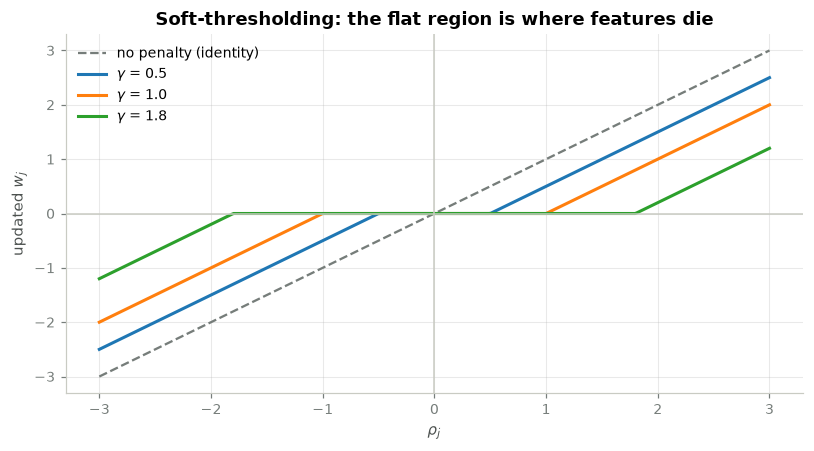

In [3]:
def soft_threshold(rho, gamma):
    """Shrink rho toward zero by gamma, and clamp at exactly zero."""
    return np.sign(rho) * max(abs(rho) - gamma, 0.0)

xs = np.linspace(-3, 3, 400)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(xs, xs, '--', color=C['ols'], label='no penalty (identity)')
for g, ls in [(0.5, '-'), (1.0, '-'), (1.8, '-')]:
    ax.plot(xs, [soft_threshold(x, g) for x in xs], ls, lw=2, label=f'$\\gamma$ = {g}')
ax.axhline(0, color='#c9cbc3', lw=1); ax.axvline(0, color='#c9cbc3', lw=1)
ax.set(xlabel=r'$\rho_j$', ylabel=r'updated $w_j$',
       title='Soft-thresholding: the flat region is where features die')
ax.legend()
plt.tight_layout(); plt.show()

### Cyclic coordinate descent

Sweep over coordinates, updating each to its exact conditional optimum until nothing
moves. Update the residual incrementally; recomputing `y - Z @ w` from scratch on every
coordinate is the usual reason an implementation is slow.

In [4]:
def coordinate_descent(Z, y, alpha, l1_ratio=1.0, tol=1e-7, max_iter=3000, verbose=False):
    """Minimise (1/2n)||y - Zw||^2 + a*r*||w||_1 + (a*(1-r)/2)*||w||^2.

    Identical to sklearn's ElasticNet objective. l1_ratio=1 is the Lasso."""
    n, p = Z.shape
    w = np.zeros(p)
    l1, l2 = alpha * l1_ratio, alpha * (1 - l1_ratio)
    col_sq = (Z ** 2).sum(0) / n
    r = y - Z @ w
    for sweep in range(max_iter):
        max_delta = 0.0
        for j in range(p):
            rho = Z[:, j] @ (r + Z[:, j] * w[j]) / n
            new = soft_threshold(rho, l1) / (col_sq[j] + l2)
            delta = new - w[j]
            if delta != 0.0:
                r -= Z[:, j] * delta          # incremental residual update
                w[j] = new
                max_delta = max(max_delta, abs(delta))
        if verbose and sweep < 4:
            obj = np.sum((y - Z @ w) ** 2) / (2 * n) + l1 * np.abs(w).sum() \
                  + l2 / 2 * (w ** 2).sum()
            print(f'  sweep {sweep + 1}: objective = {obj:.6f}, max move = {max_delta:.5f}')
        if max_delta < tol:
            break
    return w, sweep + 1

df['is_bad_weather'] = ((df.is_rain == 1) & (df.traffic_speed_kmph < 25)).astype(int)
Xtr, Xte, ytr, yte = split(df, BASE8)
Ztr, Zte, _, _ = standardize(Xtr, Xte)
ybar = ytr.mean(); yc_tr = ytr - ybar

print('first sweeps at alpha = 2:')
w_demo, iters = coordinate_descent(Ztr, yc_tr, 2.0, verbose=True)
print(f'\nconverged in {iters} sweeps')
print(pd.Series({SHORT[f]: round(float(v), 3) for f, v in zip(BASE8, w_demo)}).to_string())

first sweeps at alpha = 2:
  sweep 1: objective = 206.351351, max move = 33.21404
  sweep 2: objective = 189.651892, max move = 4.66525
  sweep 3: objective = 181.042892, max move = 2.84758
  sweep 4: objective = 175.936633, max move = 2.20095

converged in 87 sweeps
is_peak          15.525
is_rain           9.603
traffic_speed   -17.993
drivers_avail    -1.210
is_event          5.085
is_airport        6.270
is_weekend        0.000
open_requests     2.947


### Verify against scikit-learn

If these disagree by more than the solver tolerance, the objective differs: usually a
missing $1/2n$ or a stray factor of 2. Find the factor rather than tuning until the
numbers line up.

In [5]:
from sklearn.linear_model import Lasso
print(f"{'alpha':>7} {'sweeps':>7} {'max |diff|':>12} {'nnz mine':>9} {'nnz sklearn':>12}")
for a in [0.5, 2.0, 8.0]:
    mine, it = coordinate_descent(Ztr, yc_tr, a, 1.0)
    theirs = Lasso(alpha=a, fit_intercept=False, max_iter=100000, tol=1e-10).fit(
        Ztr, yc_tr).coef_
    print(f'{a:>7} {it:>7} {np.max(np.abs(mine - theirs)):>12.2e} '
          f'{int((np.abs(mine) > 1e-8).sum()):>9} {int((np.abs(theirs) > 1e-8).sum()):>12}')

  alpha  sweeps   max |diff|  nnz mine  nnz sklearn
    0.5      87     3.62e-07         7            7
    2.0      87     3.87e-07         7            7
    8.0      82     3.70e-07         6            6


### The Lasso path and the order of elimination (Deliverable 1, panel 2)

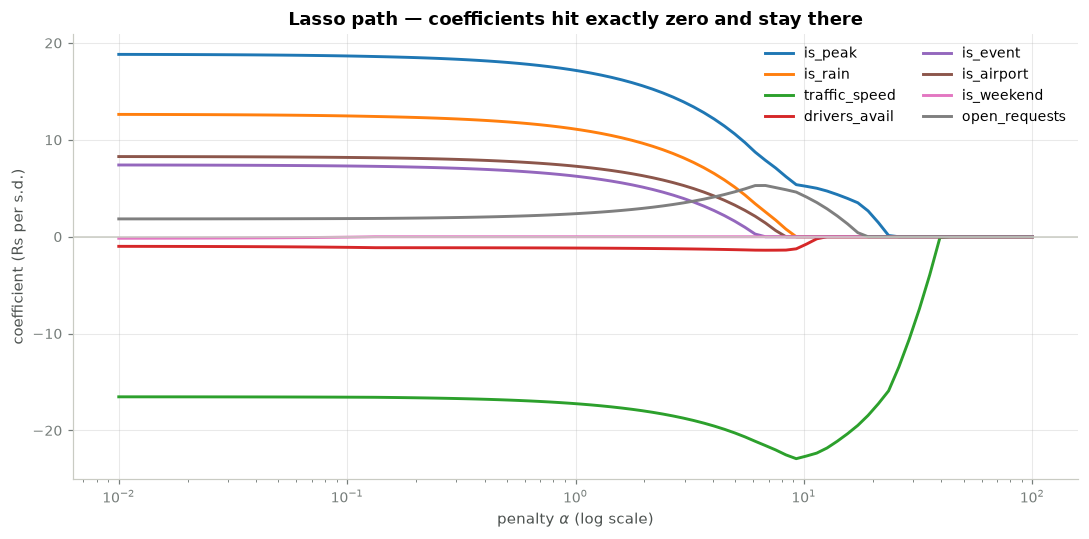

elimination order (feature, alpha at which it died):
  is_weekend       0.147
  is_event         6.784
  is_airport       8.344
  is_rain          9.253
  drivers_avail    12.622
  open_requests    19.094
  is_peak          26.045
  traffic_speed    43.697


In [6]:
alphas = np.logspace(-2, 2, 90)
paths = np.array([coordinate_descent(Ztr, yc_tr, a, 1.0)[0] for a in alphas])

fig, ax = plt.subplots(figsize=(10, 5))
for j, f in enumerate(BASE8):
    ax.plot(alphas, paths[:, j], lw=1.9, label=SHORT[f])
ax.set_xscale('log'); ax.axhline(0, color='#c9cbc3', lw=1)
ax.set(xlabel=r'penalty $\alpha$ (log scale)', ylabel='coefficient (Rs per s.d.)',
       title='Lasso path — coefficients hit exactly zero and stay there')
ax.legend(ncol=2)
plt.tight_layout(); plt.show()

order, seen = [], set()
for k, a in enumerate(alphas):
    for j in np.where(np.abs(paths[k]) < 1e-8)[0]:
        if j not in seen:
            seen.add(j); order.append((SHORT[BASE8[j]], round(float(a), 3)))
print('elimination order (feature, alpha at which it died):')
for f, a in order:
    print(f'  {f:<16} {a}')

> **Expected finding.** `is_weekend` should go first: its true coefficient is exactly
> zero, so any weight it carries is fitted noise, which is what the penalty removes. If
> something else goes first in your run, investigate before writing anything else.

---

## 3b — The new-city launch: 60 trips, 120 features

OLS is undefined here: $X^\top X$ is $120\times120$ with rank at most 60. Six features
drive surge, and **each has a decoy planted beside it** at $r \approx 0.9$. Do not open
the truth file until step 3.

In [7]:
nc = load('new_city_features.csv')
fcols = [c for c in nc.columns if c not in ('trip_id', 'surge_additive_inr')]
Xn = nc[fcols].to_numpy(float)
yn = nc['surge_additive_inr'].to_numpy(float)
Zn = (Xn - Xn.mean(0)) / np.where(Xn.std(0) == 0, 1e-8, Xn.std(0))
ync = yn - yn.mean()

print(f'{Xn.shape[0]} trips, {Xn.shape[1]} candidate features')
print(f'rank of X          : {np.linalg.matrix_rank(Xn)}')
print(f'so X^T X is {Xn.shape[1]}x{Xn.shape[1]} with rank at most {Xn.shape[0]}'
      ' -> singular, and OLS has no unique solution.')

60 trips, 120 candidate features
rank of X          : 60
so X^T X is 120x120 with rank at most 60 -> singular, and OLS has no unique solution.


In [8]:
sweep = []
for a in [1, 2, 4, 6, 8, 10, 12, 15, 20, 25]:
    w, _ = coordinate_descent(Zn, ync, a, 1.0)
    sel = [fcols[j] for j in np.where(np.abs(w) > 1e-8)[0]]
    sweep.append({'alpha': a, 'n_selected': len(sel), 'selected': sel})
print(pd.DataFrame(sweep)[['alpha', 'n_selected']].to_string(index=False))

 alpha  n_selected
     1          26
     2          18
     4          10
     6           7
     8           7
    10           7
    12           6
    15           6
    20           2
    25           1


### Now open the truth file

the six real drivers:
              feature  true_coefficient
              is_peak              38.0
              is_rain              27.0
    is_airport_pickup              24.0
      is_event_nearby              19.0
        traffic_index             -16.0
driver_scarcity_index              21.0

  alpha  n_selected   recall  precision                                                                missed
     1          26 1.000000   0.230769                                                                    []
     2          18 1.000000   0.333333                                                                    []
     4          10 1.000000   0.600000                                                                    []
     6           7 1.000000   0.857143                                                                    []
     8           7 1.000000   0.857143                                                                    []
    10           7 1.000000   0.857143    

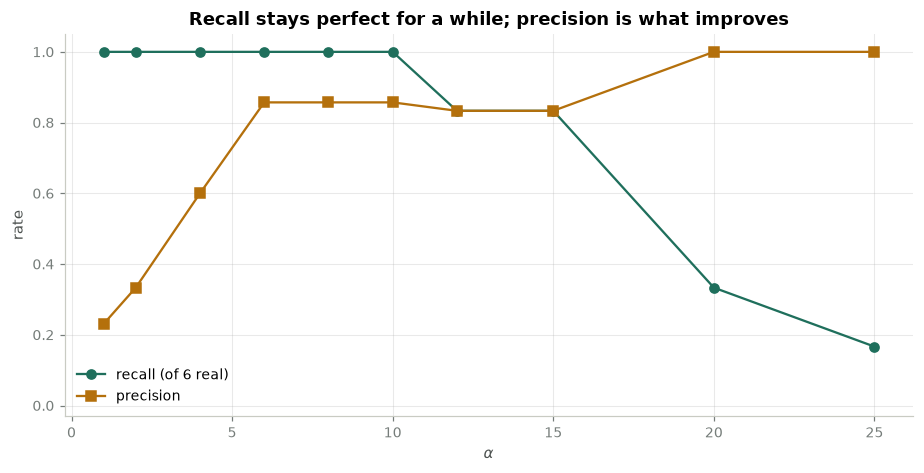

In [9]:
truth = load('new_city_truth.csv')
real = set(truth.loc[truth.true_coefficient != 0, 'feature'])
print('the six real drivers:')
print(truth[truth.true_coefficient != 0].to_string(index=False))

for row in sweep:
    sel = set(row['selected'])
    row['recall'] = len(sel & real) / len(real)
    row['precision'] = len(sel & real) / max(len(sel), 1)
    row['missed'] = sorted(real - sel)

res = pd.DataFrame(sweep)
print('\n', res[['alpha', 'n_selected', 'recall', 'precision', 'missed']].to_string(index=False))

fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.plot(res.alpha, res.recall, 'o-', color=C['accent'], label='recall (of 6 real)')
ax.plot(res.alpha, res.precision, 's-', color=C['lasso'], label='precision')
ax.set(xlabel=r'$\alpha$', ylabel='rate', ylim=(-0.03, 1.05),
       title='Recall stays perfect for a while; precision is what improves')
ax.legend()
plt.tight_layout(); plt.show()

### The interesting part: which driver dies first, and what replaces it

In [10]:
first_bad = next((r for r in sweep if r['missed']), None)
if first_bad:
    lost = first_bad['missed'][0]
    li = fcols.index(lost)
    cors = [(fcols[j], float(np.corrcoef(Xn[:, li], Xn[:, j])[0, 1]))
            for j in range(len(fcols)) if j != li]
    decoy, rv = max(cors, key=lambda c: abs(c[1]))
    kept_fakes = [f for f in first_bad['selected'] if f not in real]
    print(f"At alpha = {first_bad['alpha']}, Lasso drops '{lost}' — a REAL driver.")
    print(f"Its strongest correlate is '{decoy}' at r = {rv:.3f}.")
    print(f"Features kept that are not real: {kept_fakes}")
    print(f"\n'{decoy}' is still in the model: "
          f"{decoy in first_bad['selected']}")

At alpha = 12, Lasso drops 'is_airport_pickup' — a REAL driver.
Its strongest correlate is 'feat_003' at r = 0.956.
Features kept that are not real: ['feat_003']

'feat_003' is still in the model: True


> **Write-up prompt (Task 3b, step 4).** Lasso kept a pure-noise feature and discarded a
> genuine driver. Explain why this is expected behaviour for an $\ell_1$ penalty rather
> than a bug: the two columns carry nearly the same information, the penalty charges per
> non-zero coefficient, and nothing in the objective prefers the real one.

In [11]:
# Does Elastic Net rescue us here? Check before assuming.
comp = []
for a in [4, 6, 10, 20]:
    for rho, name in [(1.0, 'lasso'), (0.9, 'enet rho=0.9'), (0.5, 'enet rho=0.5')]:
        w, _ = coordinate_descent(Zn, ync, a, rho)
        sel = {fcols[j] for j in np.where(np.abs(w) > 1e-8)[0]}
        comp.append({'alpha': a, 'method': name, 'n_selected': len(sel),
                     'recall': round(len(sel & real) / 6, 2),
                     'precision': round(len(sel & real) / max(len(sel), 1), 3)})
print(pd.DataFrame(comp).to_string(index=False))

 alpha       method  n_selected  recall  precision
     4        lasso          10    1.00      0.600
     4 enet rho=0.9          27    1.00      0.222
     4 enet rho=0.5          72    1.00      0.083
     6        lasso           7    1.00      0.857
     6 enet rho=0.9          23    1.00      0.261
     6 enet rho=0.5          63    1.00      0.095
    10        lasso           7    1.00      0.857
    10 enet rho=0.9          20    1.00      0.300
    10 enet rho=0.5          51    1.00      0.118
    20        lasso           2    0.33      1.000
    20 enet rho=0.9           8    0.67      0.500
    20 enet rho=0.5          27    1.00      0.222


> **The counter-intuitive result.** Elastic Net at $\rho = 0.5$ has perfect recall and
> poor precision: the $\ell_2$ term resists setting coefficients to zero, so it returns
> dozens of features instead of a shortlist.
>
> The grouping effect is a virtue when the correlated partner is real (Task 4) and a
> liability when it is a decoy. Report this rather than concluding that the more elaborate
> method must be better.
>
> With $n = 60$, Lasso can select at most 60 features however small $\alpha$ gets. Check
> whether you came near that bound.

---

### Checklist

- [ ] `soft_threshold` and `coordinate_descent` written from scratch
- [ ] Matches `sklearn.Lasso` to ~1e-7 at three different $\alpha$
- [ ] Lasso path plotted; elimination order recorded; `is_weekend` dies first
- [ ] Recall and precision curves for the new city
- [ ] The real driver that gets dropped, and its decoy, both identified
- [ ] Elastic Net compared — including the result that contradicts expectation

Next: **Notebook 03 — Elastic Net and the grouping effect**.